# Example: PL maps with position scan

Multi-panel animation of a real-space linescan using `leman.plotting.animate_wl_pl_spectra`.

Three conceptual panels are available:

- **white light** real-space image sequence (`wl`)
- **real-space PL** image sequence (`pl`)
- **spectrum** line scan, one spectrum per scan point (`spectra`)

Each panel is optional: omit any argument and the figure drops to the remaining panels, so every combination (any 2, or all 3) works from the same call. There are three parts to this notebook.

- Part 1: Using the function `leman.plotting.animate_wl_pl_spectra` to plot all three panels.
- Part 2: Choosing which panels to plot with the function `leman.plotting.animate_wl_pl_spectra`
- Part 3: Full control over the plot. Allows us to control the order of the panels as well.

The data used in this notebook was collected by Felicia Iacob. We move the position of the sample stage in the y position and obtain the real-space PL map.

In [1]:
import leman as tmdc

## Part 1: All three panels

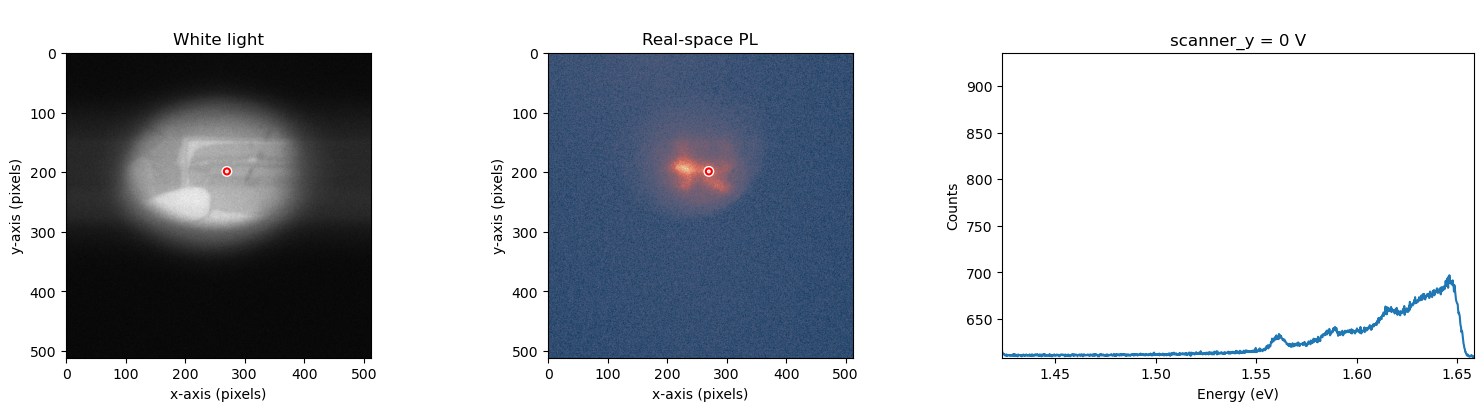

In [6]:
fig, anim, panels = tmdc.plotting.animate_wl_pl_spectra(
    wl=("./data/position-scan/wl/", "wl_"), # (path, file prefix)
    pl=("./data/position-scan/PL/", "pl_"), # (path, file prefix)
    spectra="./data/position-scan/PL/PL_26_06_26_10_19_26_iter_0.csv", 
    laser_ref="data/position-scan/laser_ref_26_06_26_10_12_56.csv",
    wl_cmap="gray",
    pl_cmap="lipari",
    interval_ms = 250,
    # save="three_panel_scan.gif", # provide argument to save plot
)

## Part 2: Only 2 panels

Here we choose only the PL map and the spectral plot. To do so, we simply leave out the argument for the `wl` image. We could also do the same for the other panels.

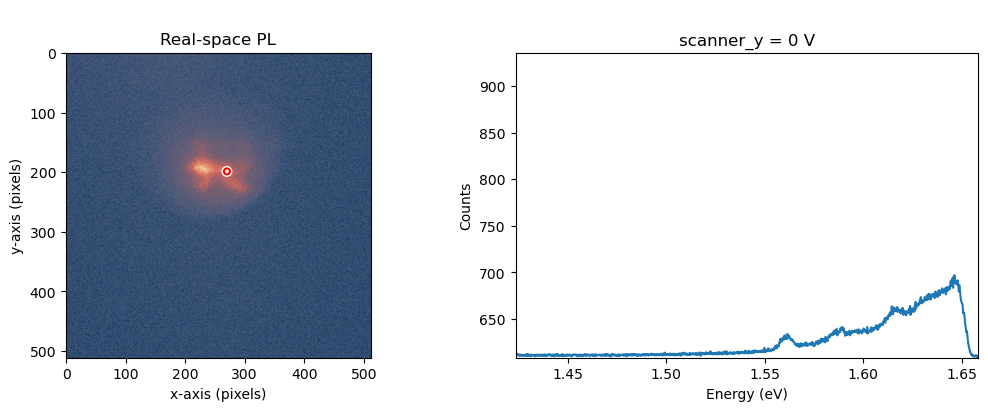

In [7]:
fig, anim, panels = tmdc.plotting.animate_wl_pl_spectra(
    # wl=("./data/position-scan/wl/", "wl_"), # (path, file prefix)
    pl=("./data/position-scan/PL/", "pl_"), # (path, file prefix)
    spectra="./data/position-scan/PL/PL_26_06_26_10_19_26_iter_0.csv", 
    laser_ref="data/position-scan/laser_ref_26_06_26_10_12_56.csv",
    wl_cmap="gray",
    pl_cmap="lipari",
    interval_ms = 250,
    # save="three_panel_scan.gif", # provide argument to save plot
)

## Part 3: Full control. Build panels yourself

For arbitrary mixes (or to reuse loaders you already have), construct the
panels and pass them to `animate_panels`. The number/order of panels in the
list determines the layout.

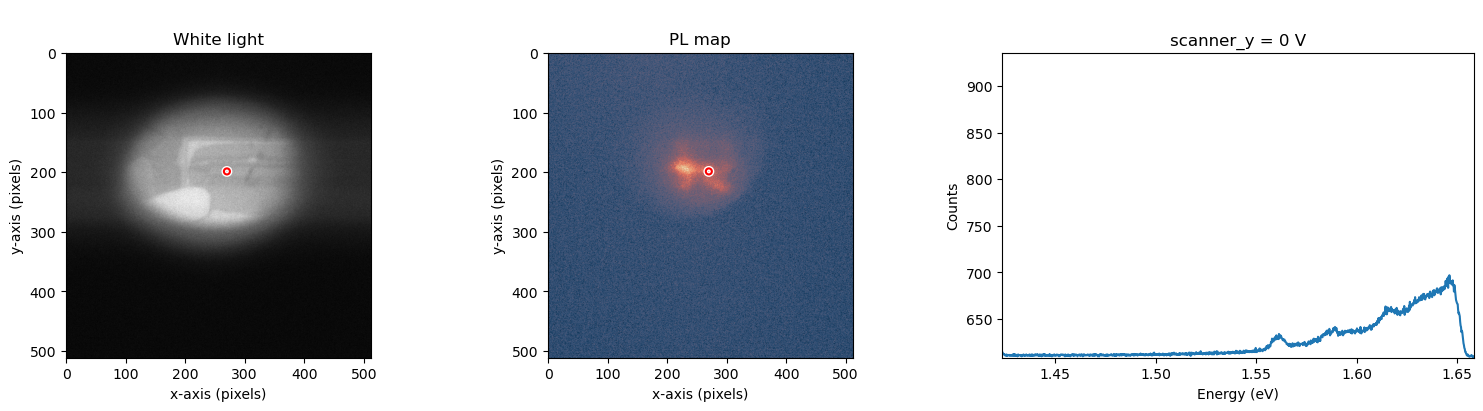

In [13]:
laser = tmdc.loaders.ACLaserRefImg(
    "./data/position-scan/laser_ref_26_06_26_10_12_56.csv", expected_radius_px=10
)

panels = [
    tmdc.plotting.ImageSequencePanel(
        tmdc.loaders.ACImgSweep("./data/position-scan/wl/", "wl_", laser_ref=laser),
        title="White light", cmap="gray",
    ),
    tmdc.plotting.ImageSequencePanel(
        tmdc.loaders.ACImgSweep("./data/position-scan/pl/", "pl_", laser_ref=laser),
        title="PL map", cmap="lipari",
    ),
    tmdc.plotting.SpectrumLinePanel(
        tmdc.loaders.ACPLVabScan("./data/position-scan/PL/pl_26_06_26_10_19_26_iter_0.csv"),
        x_axis="energy",
    ),
]

fig, anim = tmdc.plotting.animate_panels(panels)

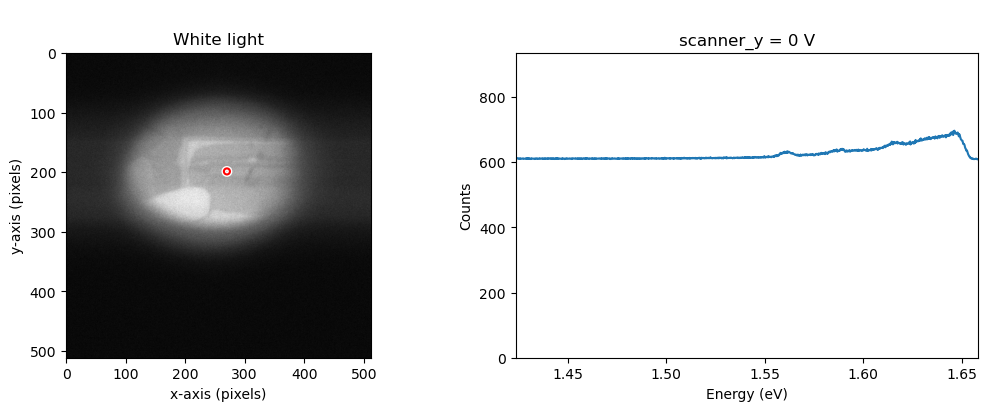

In [12]:
laser = tmdc.loaders.ACLaserRefImg(
    "./data/position-scan/laser_ref_26_06_26_10_12_56.csv", expected_radius_px=10
)

panels = [
    tmdc.plotting.ImageSequencePanel(
        tmdc.loaders.ACImgSweep("./data/position-scan/wl/", "wl_", laser_ref=laser),
        title="White light", cmap="gray",
    ),
    tmdc.plotting.SpectrumLinePanel(
        tmdc.loaders.ACPLVabScan("./data/position-scan/PL/pl_26_06_26_10_19_26_iter_0.csv"),
        x_axis="energy",
    ),
]

fig, anim = tmdc.plotting.animate_panels(panels)